## __Phase 1: Data Understanding__

### __Import packages__

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from haversine import haversine
import datetime
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

In [15]:
from scripts.visualization.map_vessel_routes_v2 import * 

### __Load raw data__

In [4]:
raw_data = pd.read_pickle("../data/raw/AIS_01_2024.pkl")
raw_data.head(5)

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,338075892,2024-01-01T00:00:03,43.65322,-70.25298,0.0,358.8,511.0,PILOT BOAT SPRING PT,NaN,WDB8945,90.0,0.0,0.0,0.0,0.0,90.0,A
1,367669550,2024-01-01T00:00:04,46.20031,-123.38573,0.0,281.9,141.0,ALASKA CHALLENGER,IMO7938024,WDH9586,30.0,15.0,30.0,8.0,0.0,30.0,A
2,367118980,2024-01-01T00:00:06,29.98534,-90.40674,0.0,30.1,296.0,CAPT J A MORGAN,IMO1186680,WDD2725,31.0,12.0,115.0,34.0,3.0,57.0,A
3,367177840,2024-01-01T00:00:05,39.88654,-75.17649,0.0,304.4,511.0,BART TURECAMO,IMO7338808,WBR4464,52.0,15.0,33.0,5.0,0.0,52.0,A
4,367305420,2024-01-01T00:00:06,18.33273,-64.95229,0.0,332.6,511.0,DOROTHY MORAN,IMO7716995,WXU4654,52.0,0.0,33.0,11.0,0.0,52.0,A


#### Dataset overview

In [ ]:
print(f"AIS dataset contains {raw_data.shape[0]} rows and {raw_data.shape[1]} columns")

print(f"Number of unique vessel types in the dataset: {raw_data['VesselType'].nunique()}")

raw_data["BaseDateTime"] = pd.to_datetime(raw_data["BaseDateTime"])
start = raw_data["BaseDateTime"].min().strftime('%Y-%m-%d %H:%M:%S')
end = raw_data["BaseDateTime"].max().strftime('%Y-%m-%d %H:%M:%S')
print(f"The dataset covers a time period from {start} to {end}")

AIS dataset contains 221958517 rows and 17 columns
Number of unique vessel types in the dataset: 83
The dataset covers a time period from 2024-01-01 00:00:00 to 2024-01-31 23:59:59.


### __Load 'cargo' data__

In [13]:
df_cargo = pd.read_parquet("../data/processed/cargo_vessels.parquet")
df_cargo.head(5)

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
49,367121040,2024-01-01 00:00:03,41.54617,-82.72934,0.0,5.5,184.0,AMERICAN COURAGE,IMO7634226,WDD2879,70.0,0.0,194.0,21.0,0.0,70.0,A
118,212719000,2024-01-01 00:00:02,34.52975,-120.94588,10.4,327.2,322.0,TROODOS SUN,IMO9698238,5BKB4,70.0,0.0,228.0,35.0,12.5,70.0,A
121,367050160,2024-01-01 00:00:03,46.75197,-92.13539,0.0,319.8,137.0,BURNS HARBOR,IMO7514713,WDC6027,70.0,0.0,330.0,34.0,8.3,70.0,A
128,538007479,2024-01-01 00:00:06,37.68875,-122.69553,6.0,356.0,7.0,HYUNDAI COURAGE,IMO9347542,V7PP4,70.0,0.0,340.0,46.0,12.5,70.0,A
133,477133500,2024-01-01 00:00:02,38.07199,-124.04890,13.1,328.2,327.0,BELLE PLAINE,IMO9638434,VRNA5,70.0,0.0,180.0,30.0,6.6,70.0,A


In [ ]:
# Select only relevant columns
relevant_columns = ["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading"]
df_cargo_selected = df_cargo[relevant_columns].reset_index(drop=True)

df_exploration = df_cargo_selected.sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True).copy()
df_cargo_selected.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
0,367121040,IMO7634226,2024-01-01 00:00:03,41.54617,-82.72934,0.0,184.0
1,212719000,IMO9698238,2024-01-01 00:00:02,34.52975,-120.94588,10.4,322.0
2,367050160,IMO7514713,2024-01-01 00:00:03,46.75197,-92.13539,0.0,137.0
3,538007479,IMO9347542,2024-01-01 00:00:06,37.68875,-122.69553,6.0,7.0
4,477133500,IMO9638434,2024-01-01 00:00:02,38.07199,-124.04890,13.1,327.0


#### Plot coverage area

In [47]:
# plot_coverage_area()

#### Plot an AIS example track

In [48]:
# plot_AIS_route(df_cargo_selected, 538009071)

#### Analyze the distribution of AIS observations per vessel

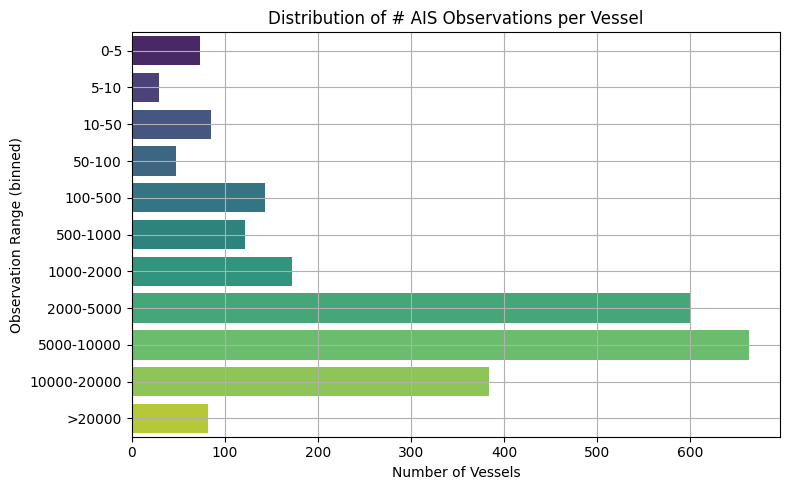

In [ ]:
# Calculate the number of observations per vessel
vessel_obs_count = df_cargo_selected.groupby(["MMSI"]).size().reset_index(name = "#obs")

bins = [0, 5, 10, 50, 100, 500, 1000, 2000, 5000, 10000, 20000, np.inf]
labels = ["0-5", "5-10", "10-50", "50-100", "100-500", "500-1000", "1000-2000", "2000-5000", "5000-10000", "10000-20000", ">20000"]

vessel_obs_count["obs_bin"] = pd.cut(
    vessel_obs_count["#obs"], 
    bins = bins, 
    labels = labels, 
    right = False
)

bin_distribution = vessel_obs_count["obs_bin"].value_counts().sort_index().reset_index()
bin_distribution.columns = ["Observation range", "Number of vessels"]

plt.figure(figsize = (8, 5))
sns.barplot(
    data = bin_distribution,  
    x = "Number of vessels", 
    y = "Observation range", 
    hue = "Observation range", 
    palette = "viridis",
    legend = False  
)

plt.title("Distribution of # AIS Observations per Vessel")
plt.xlabel("Number of Vessels")
plt.ylabel("Observation Range (binned)")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Plot the distribution of the time differences between two consecutive points

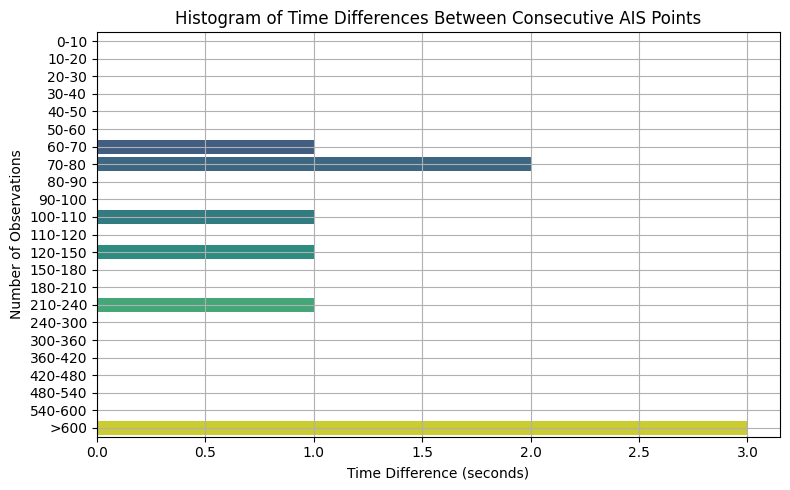

In [ ]:
# Calculate time between consecutive points
df_exploration["time_diff"] = df_exploration.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds()

bins = [
    0, 10, 20, 30, 40, 50, 60,              # 10 seconds
    70, 80, 90, 100, 110, 120,              # 10 seconds
    150, 180, 210, 240, 300,                # 30 seconds
    360, 420, 480, 540, 600, np.inf         # 60 seconds
]

labels = [
    "0-10", "10-20", "20-30", "30-40", "40-50", "50-60",                            # 10 seconds
    "60-70", "70-80", "80-90", "90-100", "100-110", "110-120",                      # 10 seconds
    "120-150", "150-180", "180-210", "210-240",                                     # 30 seconds
    "240-300", "300-360", "360-420", "420-480", "480-540", "540-600", ">600"        # 60 seconds
]

bin_distribution["time_diff_bin"] = pd.cut(df_exploration["time_diff"], bins = bins, labels = labels, right = False)
bin_distribution = bin_distribution["time_diff_bin"].value_counts().sort_index().reset_index()
bin_distribution.columns = ["Time difference (s) range", "Number of observations"]

plt.figure(figsize = (8, 5))
sns.barplot(
    data = bin_distribution,  
    x = "Number of observations", 
    y = "Time difference (s) range", 
    hue = "Time difference (s) range", 
    palette = "viridis",
    legend = False  
)

plt.title("Histogram of Time Differences Between Consecutive AIS Points")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Number of Observations")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Analysis of distance differences and speed (SOG) for vessel MMSI 538005048

In [ ]:
# Calculate distance between consecutive points using the Haversine formula
df_exploration["prev_lat"] = df_exploration.groupby("MMSI")["LAT"].shift(1)
df_exploration["prev_lon"] = df_exploration.groupby("MMSI")["LON"].shift(1)

def compute_distance(row):
    return haversine((row["prev_lat"], row["prev_lon"]), (row["LAT"], row["LON"]))
df_exploration["distance_diff"] = df_exploration.apply(compute_distance, axis=1)

# Convert 'SOG' column from knots to km/h (1 knots is 1.852 km/h)
df_exploration["SOG_kph"] = df_exploration["SOG"] * 1.852


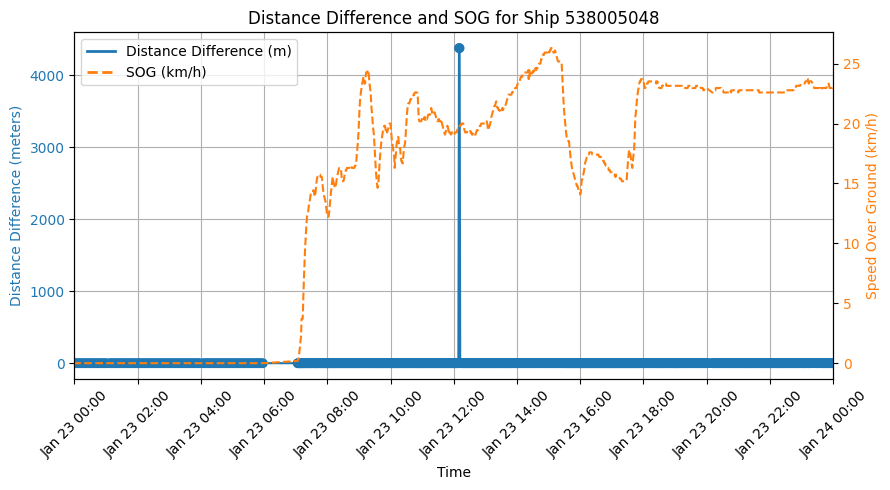

In [ ]:
# Filter on MMSI 538005048
subset = df_exploration[df_exploration["MMSI"] == 538005048]

# Plotting
fig, ax1 = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=subset,
    x="BaseDateTime",
    y="distance_diff",
    color="tab:blue",
    edgecolor="none",
    s=50,
    ax=ax1,
    zorder=3
)
sns.lineplot(data=subset, x="BaseDateTime", y="distance_diff", color="tab:blue", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=subset, x="BaseDateTime", y="SOG_kph", color="tab:orange", ax=ax2, linestyle="--")
ax2.set_ylabel("Speed Over Ground (km/h)", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")

ax1.set_xlim(datetime.datetime(2024, 1, 23), datetime.datetime(2024, 1, 24))
ax1.set_xlabel("Time")
ax1.set_ylabel("Distance Difference (meters)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_title("Distance Difference and SOG for Ship 538005048")
ax1.grid(True)

# Format x-axis labels
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Legend
custom_lines = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Distance Difference (m)"),
    Line2D([0], [0], color="tab:orange", lw=2, linestyle="--", label="SOG (km/h)")
]
ax1.legend(handles=custom_lines, loc="upper left")

plt.tight_layout()
plt.show()


In [88]:
# plot_AIS_route(df_exploration, 538005048)

#### Analysis of self-computed vessel speed

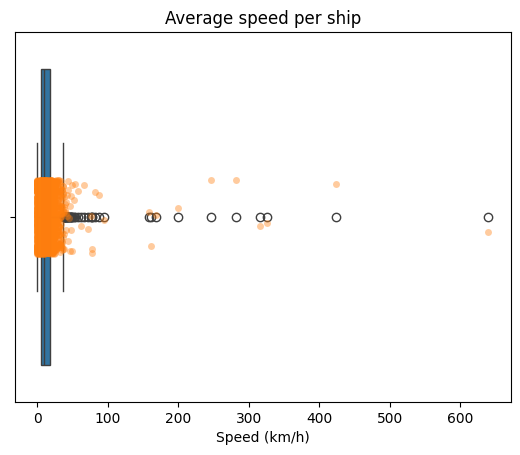

In [86]:
# Calculate 'speed_kph' based on time_diff en distance_diff
df_exploration["speed_kph"] = np.where(
    (df_exploration["time_diff"] > 0) & (df_exploration["distance_diff"] > 0),
    (df_exploration["distance_diff"] / df_exploration["time_diff"]) * 3600,
    0
)

# Create a box plot of the average speed per ship 
avg_speeds = df_exploration.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data = avg_speeds, x = "speed_kph")
sns.stripplot(data = avg_speeds, x = "speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()